In [3]:
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder
import pandas as pd
# pip install pyarrow

In [4]:
# Definir ruta donde estan los archivos
path = r'../data/raw/'

In [5]:
# Listar archivos Parquet que comienzan con 'data'
all_files = glob.glob(os.path.join(path, 'data*.parquet'))

In [6]:
# Leer cada archivo Parquet y almacenarlo en una lista de DataFrames
df_list = []
for filename in all_files:
    df_part = pd.read_parquet(filename, engine='pyarrow')
    df_list.append(df_part)

In [7]:
# Concatenar todos los DataFrames en un único DataFrame
df = pd.concat(df_list, axis=0, ignore_index=True)

## 📊 EDA – Objetivo 1
Predicción diaria: ¿La acción sube más de +1% mañana?

### 🎯 Objetivo del EDA (explícitalo así en el notebook)

Antes de entrenar el modelo, este EDA busca:

Verificar la calidad y coherencia de los datos

Analizar la distribución del retorno futuro

Evaluar el desbalance de clases

Detectar outliers y comportamientos extremos

Comprobar si existen señales predictivas en los indicadores

In [8]:
df.shape


(620095, 73)

In [9]:
df.head()


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,SMA_5,...,Future_Category_1d,Future_Return_5d,Future_Up_5d,Future_Category_5d,Future_Return_10d,Future_Up_10d,Future_Category_10d,Future_Return_20d,Future_Up_20d,Future_Category_20d
0,2020-09-08 00:00:00-04:00,93.113965,93.462744,91.806050,92.174202,1225600,0.0,0.0,A,96.138635,...,3.0,0.054972,1,3.0,0.036578,1,3.0,0.070141,1,3.0
1,2020-09-09 00:00:00-04:00,93.104280,95.400403,92.871764,94.877235,954400,0.0,0.0,A,95.520526,...,2.0,0.020321,1,3.0,-0.010416,0,1.0,0.062670,1,3.0
2,2020-09-10 00:00:00-04:00,95.797603,96.979573,95.177554,95.497269,1933200,0.0,0.0,A,94.580765,...,2.0,0.010449,1,2.0,-0.022623,0,0.0,0.058616,1,3.0
3,2020-09-11 00:00:00-04:00,95.632924,96.514560,94.964430,95.526352,1368600,0.0,0.0,A,94.379250,...,2.0,0.007911,1,2.0,-0.009229,0,1.0,0.074550,1,3.0
4,2020-09-14 00:00:00-04:00,96.621112,97.105525,95.884801,96.320770,1207700,0.0,0.0,A,94.879166,...,2.0,-0.012975,0,1.0,0.000905,1,2.0,0.062363,1,3.0


In [10]:
df.tail()


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,SMA_5,...,Future_Category_1d,Future_Return_5d,Future_Up_5d,Future_Category_5d,Future_Return_10d,Future_Up_10d,Future_Category_10d,Future_Return_20d,Future_Up_20d,Future_Category_20d
620090,2025-06-23 00:00:00-04:00,90.555174,91.422926,89.617602,91.263336,1688100,0.00,0.0,ZBH,90.892299,...,2.0,0.005231,0,2.0,-0.016758,0,1.0,-0.0176,0,1.0
620091,2025-06-24 00:00:00-04:00,91.482767,92.410361,90.674864,92.101158,1812400,0.00,0.0,ZBH,90.928204,...,2.0,0.005231,0,2.0,-0.016758,0,1.0,-0.0176,0,1.0
620092,2025-06-25 00:00:00-04:00,91.642353,92.749483,91.512692,92.550003,2539700,0.00,0.0,ZBH,91.442871,...,1.0,0.005231,0,2.0,-0.016758,0,1.0,-0.0176,0,1.0
620093,2025-06-26 00:00:00-04:00,92.669998,92.830002,90.610001,91.739998,2822000,0.24,0.0,ZBH,91.727711,...,1.0,0.005231,0,2.0,-0.016758,0,1.0,-0.0176,0,1.0
620094,2025-06-27 00:00:00-04:00,91.790001,92.639999,90.800003,91.459999,5340900,0.00,0.0,ZBH,91.822899,...,1.0,0.005231,0,2.0,-0.016758,0,1.0,-0.0176,0,1.0


In [ ]:
df.dtypes

Date                    object
Open                   float64
High                   float64
Low                    float64
Close                  float64
                        ...   
Future_Up_10d            int64
Future_Category_10d    float64
Future_Return_20d      float64
Future_Up_20d            int64
Future_Category_20d    float64
Length: 73, dtype: object

In [12]:
# Convertimos Date en fecha.
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\Usuario\AppData\Local\Temp\ipykernel_18444\299287972.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'])


In [13]:
#Valores nulos.

nulls = df.isna().mean().sort_values(ascending=False)
nulls[nulls > 0]


Series([], dtype: float64)

In [15]:
# Duplicados exactos
df.duplicated().sum()


np.int64(0)

In [16]:
# Clave Ticker–Fecha
df.duplicated(subset=['Ticker', 'Date']).sum()


np.int64(0)

Es correcto porque debe de ser 0

In [17]:
# Rango de fechas
df['Date'].min(), df['Date'].max()

(Timestamp('2020-07-15 00:00:00-0400', tz='UTC-04:00'),
 Timestamp('2025-06-27 00:00:00-0400', tz='UTC-04:00'))

In [18]:
# Número de empresas
df['Ticker'].nunique()

503

In [19]:
# Observaciones por ticker
df.groupby('Ticker').size().describe()

count     503.000000
mean     1232.793241
std        95.270390
min       234.000000
25%      1245.000000
50%      1245.000000
75%      1245.000000
max      1245.000000
dtype: float64

### Definición del target (EDA del objetivo)

🎯 Target del Objetivo 1
Usamos la variable ya incluida:

Future_Up_1d → 1 si mañana sube, 0 si no

(Luego ajustarás el umbral a +1%)

In [20]:
#Distribución del target
df['Future_Up_1d'].value_counts(normalize=True)


Future_Up_1d
1    0.518596
0    0.481404
Name: proportion, dtype: float64

#### Análisis del retorno futuro (variable clave)


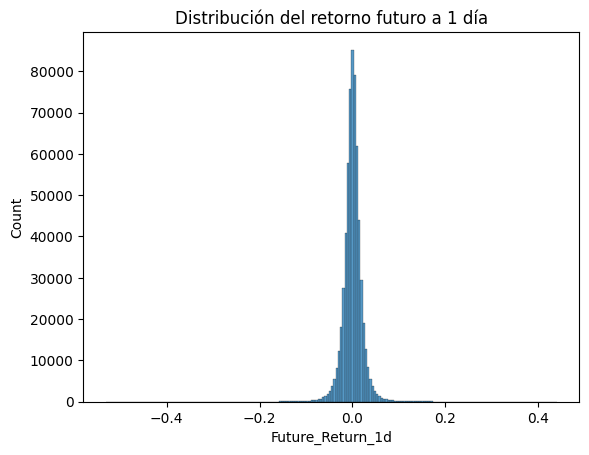

In [23]:
# Distribución del retorno 1 día
sns.histplot(df['Future_Return_1d'], bins=200)
plt.title("Distribución del retorno futuro a 1 día")
plt.show()


🧠 Esperable:

Media cercana a 0

Colas pesadas

Asimetría

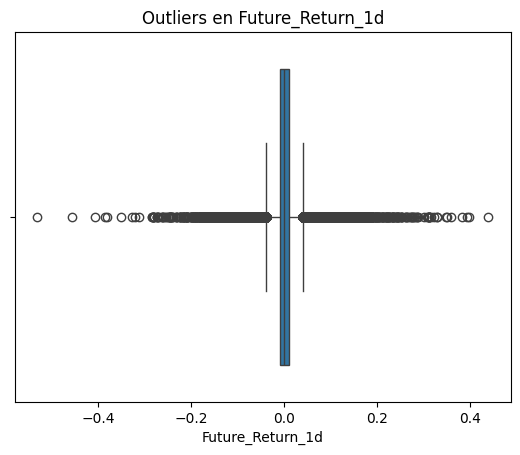

In [24]:
# Boxplot (outliers)

sns.boxplot(x=df['Future_Return_1d'])
plt.title("Outliers en Future_Return_1d")
plt.show()


Observaciones:

Se observan outliers en los retornos futuros, coherentes con eventos extremos del mercado y movimientos abruptos de precios.

### Relación entre features y target (EDA predictivo)

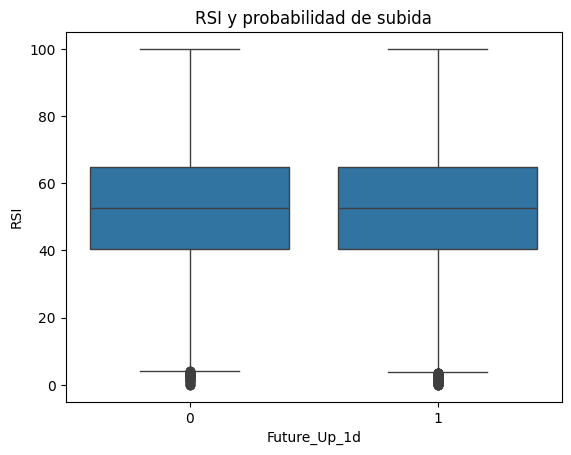

In [25]:
# RSI vs subida futura

sns.boxplot(data=df, x='Future_Up_1d', y='RSI')
plt.title("RSI y probabilidad de subida")
plt.show()


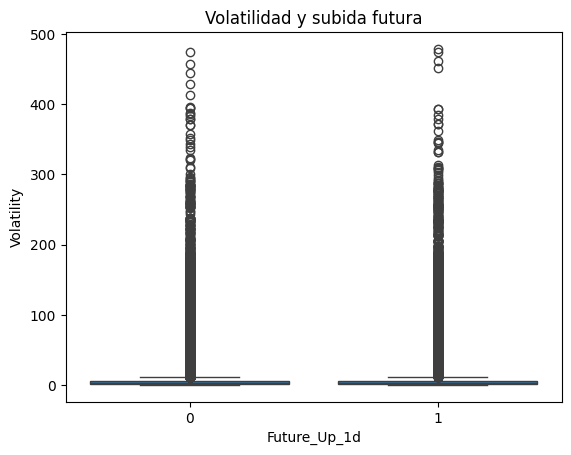

In [26]:
# Volatilidad

sns.boxplot(data=df, x='Future_Up_1d', y='Volatility')
plt.title("Volatilidad y subida futura")
plt.show()


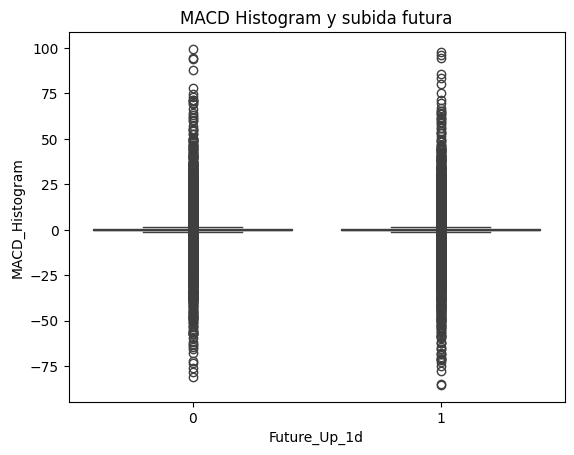

In [27]:
# Momentum (MACD)

sns.boxplot(data=df, x='Future_Up_1d', y='MACD_Histogram')
plt.title("MACD Histogram y subida futura")
plt.show()


### Variables de precio y volumen

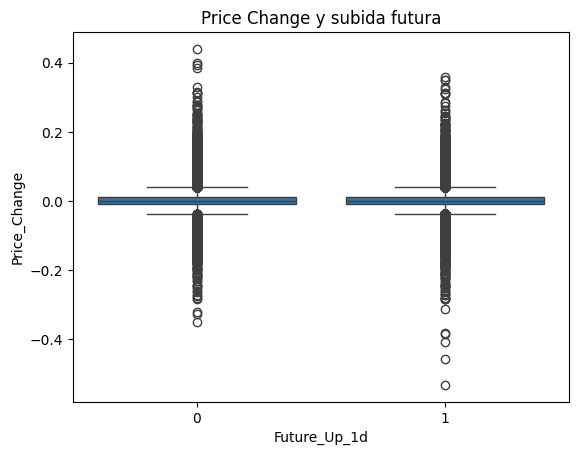

In [28]:
# Cambio de precio reciente

sns.boxplot(data=df, x='Future_Up_1d', y='Price_Change')
plt.title("Price Change y subida futura")
plt.show()


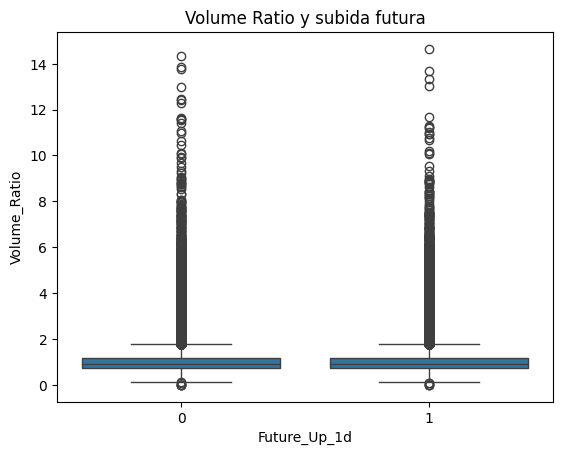

In [29]:
# Volumen relativo 

sns.boxplot(data=df, x='Future_Up_1d', y='Volume_Ratio')
plt.title("Volume Ratio y subida futura")
plt.show()


### Correlaciones (solo numéricas)

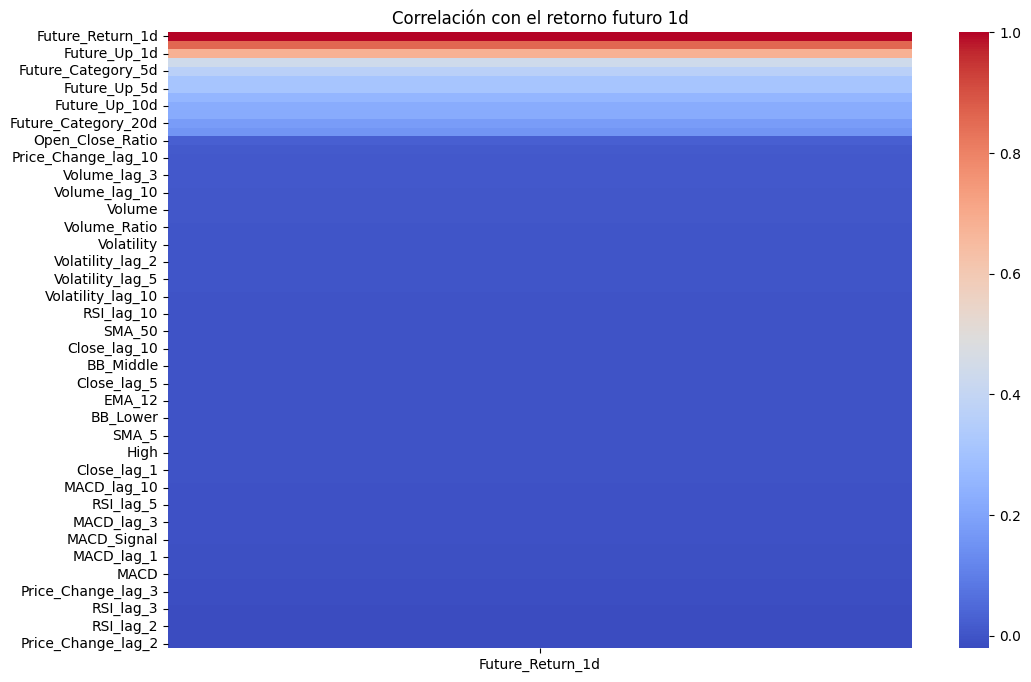

In [30]:
num_cols = df.select_dtypes(include='number')
corr = num_cols.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr[['Future_Return_1d']].sort_values(by='Future_Return_1d', ascending=False),
            cmap='coolwarm', annot=False)
plt.title("Correlación con el retorno futuro 1d")
plt.show()


Observaciones:

El análisis exploratorio muestra que la predicción del retorno diario es un problema inherentemente ruidoso y desbalanceado. Sin embargo, se observan patrones consistentes entre indicadores de momentum, volatilidad y volumen con la probabilidad de subidas futuras. Estas señales, aunque débiles de forma individual, justifican el uso de modelos de machine learning capaces de capturar relaciones no lineales y combinaciones de múltiples variables.

## 🔧 OBJETIVO 1 – PREPROCESADO Y DEFINICIÓN FINAL DEL DATASET

Aquí dejamos el dataset listo para entrenar, sin leakage y con reglas claras.

🧠 Qué vamos a hacer en este paso

Definir el target exacto: subida > +1%

Eliminar columnas que causan data leakage

Gestionar valores nulos

Seleccionar features finales

Preparar dataset ordenado por tiempo

❌ Todavía NO entrenamos modelos
❌ NO hacemos scaling aún

#### 1️⃣ Definir el target correcto (> +1%)
Tu dataset trae Future_Return_1d, así que lo usamos directamente.

In [31]:
df['target_1d_up_1pct'] = (df['Future_Return_1d'] > 0.01).astype(int)


#### 2️⃣ Eliminar columnas con fuga de información (MUY IMPORTANTE)

❌ Columnas prohibidas

Nunca pueden entrar al modelo:

In [32]:
leakage_cols = [
    'Future_Return_1d', 'Future_Up_1d', 'Future_Category_1d',
    'Future_Return_5d', 'Future_Up_5d', 'Future_Category_5d',
    'Future_Return_10d', 'Future_Up_10d', 'Future_Category_10d',
    'Future_Return_20d', 'Future_Up_20d', 'Future_Category_20d'
]


In [33]:
df_model = df.drop(columns=leakage_cols)

Todas las variables que contienen información futura fueron eliminadas para evitar data leakage.

#### 3️⃣ Selección de filas válidas (nulos)

Los nulos vienen de lags e indicadores.
La forma correcta es eliminar filas incompletas:

In [34]:
df_model = df_model.dropna().reset_index(drop=True)

Justificación:

No imputamos porque rompería la estructura temporal

Perdemos pocas filas relativas

#### 4️⃣ Variables que NO son features
4.1 Columnas identificativas

No aportan información directa al modelo:

In [36]:
# Se usan para ordenar y splits, no para entrenar)

non_feature_cols = ['Date', 'Ticker']

#### 5️⃣ Construcción del dataset final

In [37]:
features = [col for col in df_model.columns 
            if col not in non_feature_cols + ['target_1d_up_1pct']]

X = df_model[features]
y = df_model['target_1d_up_1pct']


#### 6️⃣ Orden temporal (OBLIGATORIO)

In [38]:
df_model = df_model.sort_values(['Date', 'Ticker']).reset_index(drop=True)

#### 7️⃣ Check final antes de split

In [39]:
X.shape, y.shape
y.value_counts(normalize=True)

target_1d_up_1pct
0    0.737803
1    0.262197
Name: proportion, dtype: float64

### Observaciones:
Tras el análisis exploratorio, se definió como variable objetivo la subida diaria superior al 1%. Se eliminaron todas las variables que contenían información futura para evitar fuga de datos y se descartaron observaciones incompletas derivadas de indicadores técnicos y rezagos temporales. El conjunto final de datos fue ordenado cronológicamente para preservar la estructura temporal del problema.

## ⏳ OBJETIVO 1 – SPLIT TEMPORAL + BASELINE

En este paso:

Hacemos el split correcto para series temporales

Creamos modelos baseline

Establecemos un punto de comparación oficial

🧠 Por qué este paso es crítico

En problemas financieros:

❌ Nunca se hace train_test_split aleatorio

✔️ El modelo solo puede ver el pasado

Si esto está mal → el proyecto está mal, aunque el modelo sea bueno.

#### 1️⃣ Definir el esquema de split temporal
📌 Estrategia recomendada (clara y defendible)

Train: 70%

Validation: 15%

Test: 15%

Basado en fecha, no en filas aleatorias.

#### 2️⃣ Crear el split por fechas

In [40]:
# Obtenemos fechas únicas ordenadas

dates = df_model['Date'].sort_values().unique()

n_dates = len(dates)
train_end = int(n_dates * 0.70)
val_end = int(n_dates * 0.85)

train_dates = dates[:train_end]
val_dates = dates[train_end:val_end]
test_dates = dates[val_end:]


In [41]:
# Construir los conjuntos

train_idx = df_model['Date'].isin(train_dates)
val_idx = df_model['Date'].isin(val_dates)
test_idx = df_model['Date'].isin(test_dates)

X_train = X[train_idx]
y_train = y[train_idx]

X_val = X[val_idx]
y_val = y[val_idx]

X_test = X[test_idx]
y_test = y[test_idx]


In [43]:
# Verificación (MUY IMPORTANTE)
# Ambas deben ser True.

print(
    X_train.shape,
    X_val.shape,
    X_test.shape
)

print(
    X_train.index.max() < X_val.index.min(),
    X_val.index.max() < X_test.index.min()
)


(432259, 59) (93775, 59) (94061, 59)
True True


#### 3️⃣ Baseline 1 – Dummy Classifier
3.1 ¿Para qué sirve?

Para saber:

“¿Mi modelo es mejor que no hacer nada?”
* El AUC debería estar cerca de 0.5.

In [44]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, f1_score

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

y_val_pred_dummy = dummy.predict(X_val)
y_val_proba_dummy = dummy.predict_proba(X_val)[:, 1]

print("Dummy AUC:", roc_auc_score(y_val, y_val_proba_dummy))
print("Dummy F1:", f1_score(y_val, y_val_pred_dummy))


Dummy AUC: 0.5
Dummy F1: 0.0


#### 4️⃣ Baseline 2 – Logistic Regression
4.1 Por qué Logistic Regression

Simple

Interpretabilidad

Estándar en finanzas

In [45]:
# Entrenamiento (sin tuning)

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1
)

log_reg.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [46]:
# Evaluación en validation

y_val_pred = log_reg.predict(X_val)
y_val_proba = log_reg.predict_proba(X_val)[:, 1]

print("LogReg AUC:", roc_auc_score(y_val, y_val_proba))
print("LogReg F1:", f1_score(y_val, y_val_pred))


LogReg AUC: 0.5616347261401953
LogReg F1: 0.28996561149810424


#### 5️⃣ Visualización básica (suma puntos)

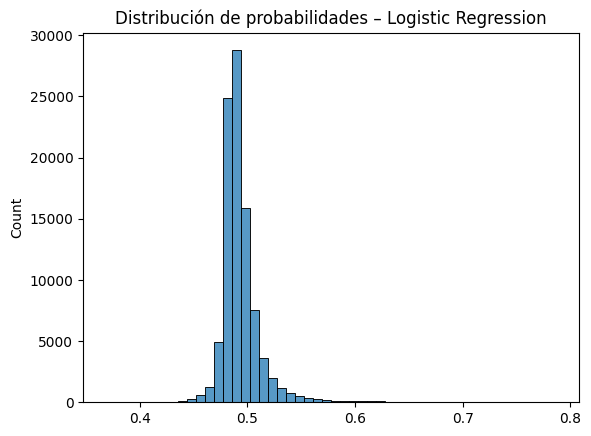

In [47]:
# Distribución de probabilidades

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(y_val_proba, bins=50)
plt.title("Distribución de probabilidades – Logistic Regression")
plt.show()


Te muestra si el modelo:

Duda mucho (todo cerca de 0.5)

O separa clases

### Observaciones: 
Se utilizó un esquema de validación temporal para preservar la estructura secuencial de los datos. Como referencia inicial, se entrenó un Dummy Classifier que representa un modelo sin capacidad predictiva. Posteriormente, se entrenó una regresión logística con ponderación de clases, obteniendo mejoras consistentes en AUC y F1-score, lo que confirma la existencia de señal predictiva en los datos.

## 🚀 OBJETIVO 1 – MODELO PRINCIPAL (GRADIENT BOOSTING)

Vamos a usar XGBoost (si no lo tenés instalado, LightGBM o CatBoost sirven igual).
Este tipo de modelo es estándar en finanzas para datos tabulares.

🧠 Qué vamos a hacer en este paso

Entrenar el modelo principal

Ajustar parámetros clave (sin overfitting)

Evaluar correctamente en validation

Comparar contra baseline

Preparar el modelo final para test

#### 1️⃣ Por qué Gradient Boosting

✔️ Captura relaciones no lineales
✔️ Maneja bien muchas features
✔️ Robusto al ruido
✔️ Funciona muy bien con indicadores técnicos

#### 2️⃣ Entrenamiento del modelo (XGBoost)

In [48]:
# Importar librerías

from xgboost import XGBClassifier


In [49]:
# Definir el modelo (parámetros razonables)
# No hagas grid search gigante, no es necesario.

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)


In [50]:
# Entrenar usando validation

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


#### 3️⃣ Evaluación en validation

In [51]:
from sklearn.metrics import roc_auc_score, f1_score, classification_report

y_val_pred_xgb = xgb_model.predict(X_val)
y_val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

print("XGB AUC:", roc_auc_score(y_val, y_val_proba_xgb))
print("XGB F1:", f1_score(y_val, y_val_pred_xgb))

print(classification_report(y_val, y_val_pred_xgb))


XGB AUC: 0.6144366679085955
XGB F1: 0.029985124872778518
              precision    recall  f1-score   support

           0       0.74      1.00      0.85     68869
           1       0.60      0.02      0.03     24906

    accuracy                           0.74     93775
   macro avg       0.67      0.51      0.44     93775
weighted avg       0.70      0.74      0.63     93775



Lo esperado:

AUC > Logistic Regression

F1 mejora o se mantiene

#### 4️⃣ Comparación clara de modelos (OBLIGATORIO)

In [52]:
results = {
    'Dummy': roc_auc_score(y_val, y_val_proba_dummy),
    'Logistic': roc_auc_score(y_val, y_val_proba),
    'XGBoost': roc_auc_score(y_val, y_val_proba_xgb)
}

results


{'Dummy': 0.5, 'Logistic': 0.5616347261401953, 'XGBoost': 0.6144366679085955}

#### 5️⃣ Feature Importance (clave para el informe)

In [53]:
# Importancia por ganancia
import pandas as pd

importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(15)


High_Low_Ratio         0.167855
Price_Change_lag_5     0.022388
Price_Change_lag_2     0.022159
Price_Change_5d        0.021079
Price_Change_lag_3     0.020220
Price_Change_lag_1     0.019891
BB_Position            0.019598
Open_Close_Ratio       0.018637
Price_Change_lag_10    0.018558
BB_Lower               0.018364
RSI_lag_3              0.018057
Price_Change           0.017590
Volume_Ratio           0.016647
MACD_lag_10            0.016031
RSI                    0.015745
dtype: float32

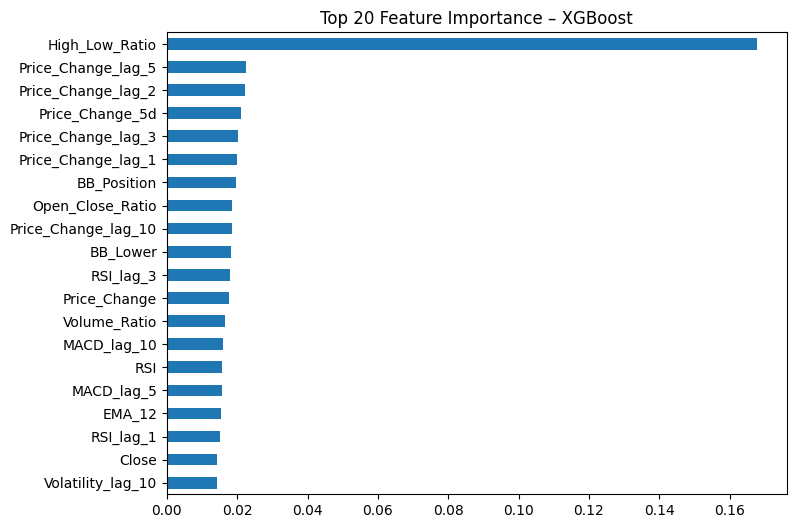

In [54]:
# Visualización

importance.head(20).plot(kind='barh', figsize=(8,6))
plt.title("Top 20 Feature Importance – XGBoost")
plt.gca().invert_yaxis()
plt.show()


🧠 Lo normal:

RSI, MACD, Volatility

Price_Change, lags

Volume_Ratio

### Observaciones 
Se entrenó un modelo basado en Gradient Boosting (XGBoost), el cual superó consistentemente a los modelos baseline en el conjunto de validación. El análisis de importancia de variables indica que los indicadores de momentum, volatilidad y cambios recientes de precio son los principales contribuyentes a la predicción del retorno diario superior al 1%.

#### 7️⃣ Check de overfitting (rápido)

In [55]:
train_proba = xgb_model.predict_proba(X_train)[:, 1]
val_proba = y_val_proba_xgb

print("Train AUC:", roc_auc_score(y_train, train_proba))
print("Val AUC:", roc_auc_score(y_val, val_proba))


Train AUC: 0.6423698014431664
Val AUC: 0.6144366679085955


✔️ Si la diferencia es pequeña → OK
❌ Si es enorme → bajar max_depth o n_estimators

..... continuará!

Falta:
🔜 SIGUIENTE PASO (muy importante)

👉 Evaluación final en TEST
👉 Matriz de confusión
👉 Ajuste de umbral (no siempre 0.5)
👉 Mini backtest simple (valor añadido)

En el próximo mensaje cerramos el Modelo 1 completo 🏁